# EDA and Data Cleaning: Cars93 Dataset

This notebook performs exploratory data analysis (EDA) and cleaning on the **Cars93** dataset, a classic dataset of 1993 car models containing intentionally-introduced missing values, making it well-suited for practicing data cleaning techniques.

**Steps covered:**
1. Load the raw dataset
2. Initial inspection (shape, data types, missing values, duplicates)
3. Data cleaning (handling missing values)
4. Visualization (distributions, outliers, correlations)
5. Export the cleaned dataset


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Raw Dataset

In [2]:
df = pd.read_csv("../data/raw_dataset.csv", na_values=["NA"])
df.head()

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,Acura,Integra,Small,12.9,15.9,18.8,25.0,31.0,NaN,Front,...,5.0,177.0,102.0,68.0,37.0,26.5,NaN,2705.0,non-USA,Acura Integra
1,NaN,Legend,Midsize,29.2,33.9,38.7,18.0,25.0,Driver & Passenger,Front,...,5.0,195.0,115.0,71.0,38.0,30.0,15.0,3560.0,non-USA,Acura Legend
2,Audi,90,Compact,25.9,29.1,32.3,20.0,26.0,Driver only,Front,...,5.0,180.0,102.0,67.0,37.0,28.0,14.0,3375.0,non-USA,Audi 90
3,Audi,100,Midsize,NaN,37.7,44.6,19.0,26.0,Driver & Passenger,NaN,...,6.0,193.0,106.0,NaN,37.0,31.0,17.0,3405.0,non-USA,Audi 100
4,BMW,535i,Midsize,NaN,30.0,NaN,22.0,30.0,NaN,Rear,...,4.0,186.0,109.0,69.0,39.0,27.0,13.0,3640.0,non-USA,BMW 535i


## 3. Initial Inspection

In [3]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (93, 27)
<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manufacturer        89 non-null     str    
 1   Model               92 non-null     str    
 2   Type                90 non-null     str    
 3   Min.Price           86 non-null     float64
 4   Price               91 non-null     float64
 5   Max.Price           88 non-null     float64
 6   MPG.city            84 non-null     float64
 7   MPG.highway         91 non-null     float64
 8   AirBags             55 non-null     str    
 9   DriveTrain          86 non-null     str    
 10  Cylinders           88 non-null     str    
 11  EngineSize          91 non-null     float64
 12  Horsepower          86 non-null     float64
 13  RPM                 90 non-null     float64
 14  Rev.per.mile        87 non-null     float64
 15  Man.trans.avail     88 non-null     st

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n")
print(missing)
print("\nTotal missing cells:", df.isnull().sum().sum())

Columns with missing values:

AirBags               38
Luggage.room          19
MPG.city               9
Fuel.tank.capacity     8
Weight                 7
Min.Price              7
DriveTrain             7
Horsepower             7
Rev.per.mile           6
Width                  6
Cylinders              5
Origin                 5
Max.Price              5
Turn.circle            5
Man.trans.avail        5
Manufacturer           4
Rear.seat.room         4
Length                 4
Type                   3
Make                   3
RPM                    3
Price                  2
MPG.highway            2
Passengers             2
EngineSize             2
Model                  1
Wheelbase              1
dtype: int64

Total missing cells: 170


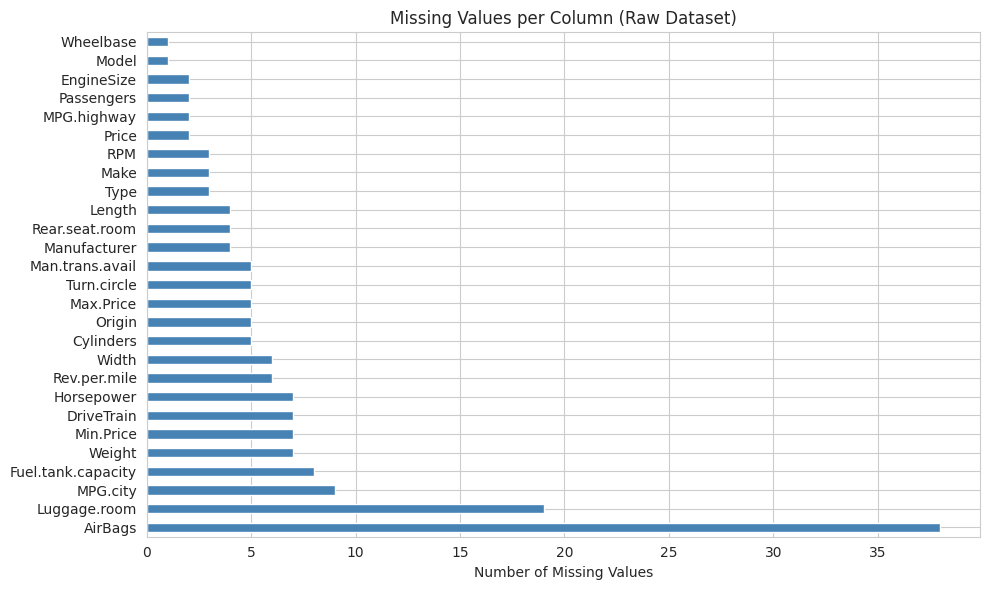

In [5]:
plt.figure(figsize=(10, 6))
missing.plot(kind="barh", color="steelblue")
plt.title("Missing Values per Column (Raw Dataset)")
plt.xlabel("Number of Missing Values")
plt.tight_layout()
plt.savefig("../docs/missing_values.png", dpi=120)
plt.show()

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df.describe()

,Min.Price,Price,Max.Price,MPG.city,MPG.highway,EngineSize,Horsepower,RPM,Rev.per.mile,Fuel.tank.capacity,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight
count,86.000000,91.000000,88.000000,84.000000,91.000000,91.000000,86.000000,90.000000,87.000000,85.000000,91.000000,89.000000,92.000000,87.000000,88.000000,89.000000,74.000000,86.000000
mean,17.118605,19.616484,21.459091,22.404762,29.065934,2.658242,144.000000,5276.666667,2355.000000,16.683529,5.076923,182.865169,103.956522,69.448276,38.954545,27.853933,13.986486,3104.593023
std,8.828290,9.724280,10.696563,5.841520,5.370293,1.045845,53.455204,605.554811,486.916616,3.375748,1.045953,14.792651,6.856317,3.778023,3.304157,3.018129,3.120824,600.129993
min,6.700000,7.400000,7.900000,15.000000,20.000000,1.000000,55.000000,3800.000000,1320.000000,9.200000,2.000000,141.000000,90.000000,60.000000,32.000000,19.000000,6.000000,1695.000000
25%,10.825000,12.350000,14.575000,18.000000,26.000000,1.800000,100.750000,4800.000000,2017.500000,14.500000,4.000000,174.000000,98.000000,67.000000,36.000000,26.000000,12.000000,2647.500000
50%,14.600000,17.700000,19.150000,21.000000,28.000000,2.300000,140.000000,5200.000000,2360.000000,16.500000,5.000000,181.000000,103.000000,69.000000,39.000000,27.500000,14.000000,3085.000000
75%,20.250000,23.500000,24.825000,25.000000,31.000000,3.250000,170.000000,5787.500000,2565.000000,19.000000,6.000000,192.000000,110.000000,72.000000,42.000000,30.000000,16.000000,3567.500000
max,45.400000,61.900000,80.000000,46.000000,50.000000,5.700000,300.000000,6500.000000,3755.000000,27.000000,8.000000,219.000000,119.000000,78.000000,45.000000,36.000000,22.000000,4105.000000


## 4. Data Cleaning

Cleaning approach:
- **Numeric columns:** fill missing values with the column **median** (robust to outliers).
- **Categorical (text) columns:** fill missing values with the column **mode** (most frequent value).
- **Text columns:** strip leading/trailing whitespace for consistency.
- **Duplicates:** drop any exact duplicate rows (none found in this dataset, but the check is included for completeness).


In [8]:
df_clean = df.copy()

# Drop exact duplicate rows, if any
df_clean = df_clean.drop_duplicates()

# Separate column types
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=["object"]).columns

# Impute numeric columns with median
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical columns with mode, then strip whitespace
for col in categorical_cols:
    mode_val = df_clean[col].mode(dropna=True)
    fill_val = mode_val[0] if not mode_val.empty else "Unknown"
    df_clean[col] = df_clean[col].fillna(fill_val)
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("Missing values after cleaning:", df_clean.isnull().sum().sum())
print("Shape after cleaning:", df_clean.shape)

Missing values after cleaning: 0
Shape after cleaning: (93, 27)


/tmp/ipykernel_543/2819332918.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=["object"]).columns


In [9]:
df_clean.to_csv("../data/cleaned_dataset.csv", index=False)
print("Cleaned dataset saved to ../data/cleaned_dataset.csv")

Cleaned dataset saved to ../data/cleaned_dataset.csv


## 5. Visualization

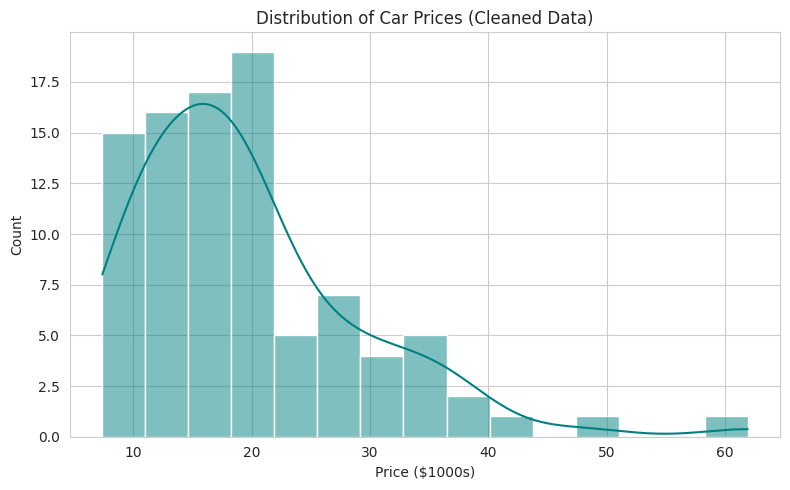

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Price"], bins=15, kde=True, color="teal")
plt.title("Distribution of Car Prices (Cleaned Data)")
plt.xlabel("Price ($1000s)")
plt.tight_layout()
plt.savefig("../docs/price_distribution.png", dpi=120)
plt.show()

/tmp/ipykernel_543/3585813237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Type", y="Price", palette="Set2")


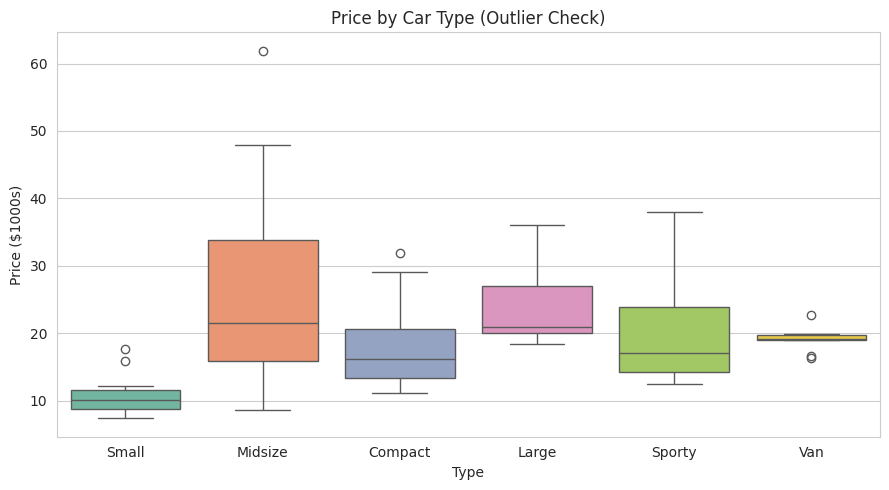

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Type", y="Price", palette="Set2")
plt.title("Price by Car Type (Outlier Check)")
plt.xlabel("Type")
plt.ylabel("Price ($1000s)")
plt.tight_layout()
plt.savefig("../docs/price_by_type_boxplot.png", dpi=120)
plt.show()

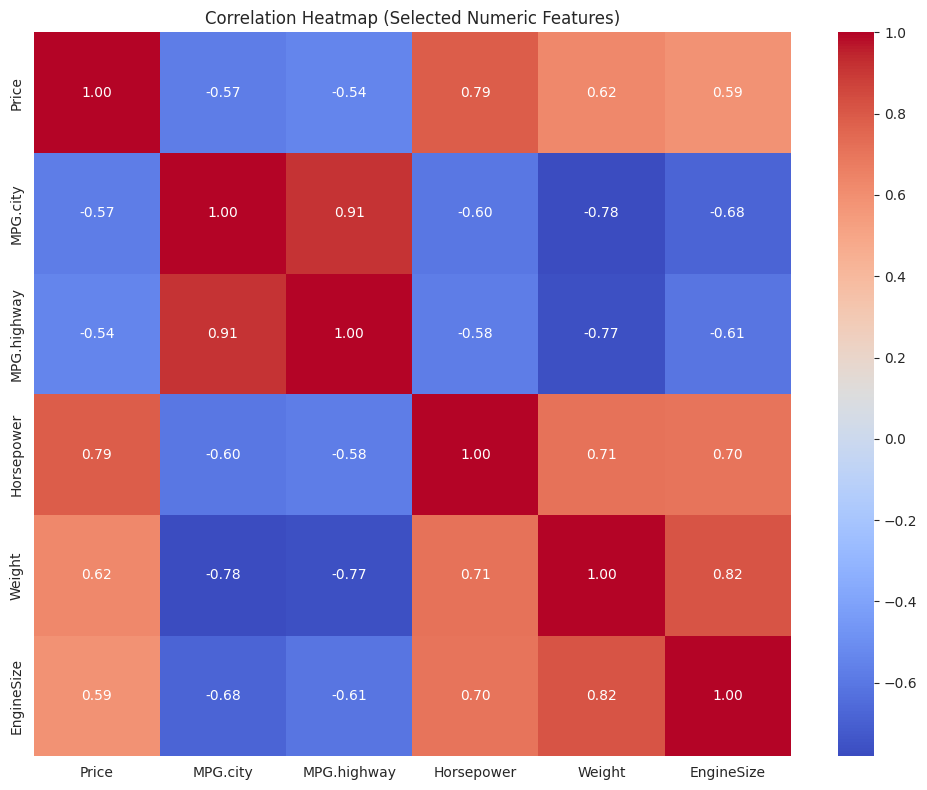

In [12]:
plt.figure(figsize=(10, 8))
corr = df_clean[["Price", "MPG.city", "MPG.highway", "Horsepower", "Weight", "EngineSize"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Selected Numeric Features)")
plt.tight_layout()
plt.savefig("../docs/correlation_heatmap.png", dpi=120)
plt.show()

## 6. Key Insights

- The raw dataset had **170 missing cells** spread across nearly every column, with `AirBags` (38 missing) and `Luggage.room` (19 missing) the most affected.
- No duplicate rows were found.
- After cleaning (median imputation for numeric columns, mode imputation for categorical columns), the dataset has **zero missing values** and is ready for analysis or modeling.
- Car prices are right-skewed — most cars are moderately priced, with a smaller number of higher-end outliers, visible in both the histogram and the boxplot by type.
- `Weight` and `Horsepower` show a strong positive correlation with `Price`, while `MPG.city` and `MPG.highway` are negatively correlated with `Price` — heavier, more powerful cars tend to cost more and be less fuel-efficient.
